In [17]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 🧠 Étape 5 : Modélisation (Machine Learning & Deep Learning) (Squelette Étudiant)

Cette étape correspond au cinquième chapitre du cours. L'objectif est d'implémenter d'une part un modèle de Machine Learning tabulaire (ex: RandomForest) et d'autre part un réseau de neurones convolutif (CNN) sous TensorFlow pour traiter des images ou signaux complexes.

### 1. Préparation de l'environnement

In [18]:
import os
import sys
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras import layers, models

sys.path.append(os.path.abspath('..'))
from src import data_clean as dc

print("Librairies de modélisation importées avec succès !")
print("Version TensorFlow :", tf.__version__)

Librairies de modélisation importées avec succès !
Version TensorFlow : 2.21.0


### 2. Modélisation Tabulaire (Machine Learning)

**À COMPLÉTER PAR L'ÉTUDIANT :**
Entraînez un modèle d'apprentissage supervisé (ex: forêt aléatoire) sur les caractéristiques extraites de votre jeu de données.

In [19]:
# Chargement des données propres et ingénierie des caractéristiques
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')


# ÉTAPE 2 — Feature Engineering
# On crée de nouvelles colonnes utiles pour l'IA
# car les algorithmes ont besoin de nombres

df['duration_min'] = df['duration_ms'] / 60000
df['is_popular'] = (df['popularity'] >= 50).astype(int)
df['dance_energy_score'] = df['danceability'] * df['energy']
df['explicit_int'] = df['explicit'].astype(int)


# ÉTAPE 3 — Définir les variables du modèle
# features = ce qu'on donne à l'IA pour apprendre
# target   = ce qu'on veut qu'elle prédise

features = [
    'danceability', 'energy', 'loudness', 
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 
    'duration_min', 'dance_energy_score', 'explicit_int'
]
target = 'popularity'

# ÉTAPE 4 — Split Train / Test
# On garde 80% des données pour entraîner l'IA
# et 20% pour tester si elle prédit bien
split = int(len(df) * 0.8)
X_train = df[features].iloc[:split]
X_test  = df[features].iloc[split:]
y_train = df[target].iloc[:split]
y_test  = df[target].iloc[split:]

print(f"Train : {len(X_train)} chansons")
print(f"Test  : {len(X_test)} chansons")

# TODO: Instancier et entraîner RandomForestRegressor sur (X_train, y_train)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Modèle de forêt aléatoire entraîné !")

Train : 77816 chansons
Test  : 19454 chansons
Modèle de forêt aléatoire entraîné !


In [20]:
# Évaluation du RandomForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

resultats = pd.DataFrame({
    'Métrique': ['MAE', 'RMSE', 'R²'],
    'Valeur': [round(mae, 3), round(rmse, 3), round(r2, 3)],
    'Interprétation': [
        'Erreur moyenne en points',
        'Erreur quadratique',
        'Qualité (1=parfait, 0=nul)'
    ]
})
display(resultats)

,Métrique,Valeur,Interprétation
0,MAE,11.128,Erreur moyenne en points
1,RMSE,14.846,Erreur quadratique
2,R²,0.230,"Qualité (1=parfait, 0=nul)"


### 3. Modélisation Vision / Deep Learning (CNN & TensorFlow)

**À COMPLÉTER PAR L'ÉTUDIANT :**
Pour des motifs complexes (images/signaux), mettez en place un réseau convolutif (Conv2D, Pooling, Dense) pour classifier ou enrichir vos prédictions.

In [21]:
# Génération fictive d'un jeu d'images simples (64x64 pixels) de cercles (Classe 0) vs rectangles (Classe 1)
def generate_dummy_images(num_samples=100):
    images = np.zeros((num_samples, 64, 64, 3), dtype=np.float32)
    labels = np.zeros(num_samples, dtype=np.int32)
    for i in range(num_samples):
        label = np.random.choice([0, 1])
        labels[i] = label
        images[i, :, :, :] = 0.2 + np.random.normal(0, 0.01, (64, 64, 3))
        if label == 1:
            images[i, 10:30, 10:30, 0] = 0.8
        else:
            images[i, 20:40, 20:40, 1] = 0.8
    return images, labels

X_images, y_labels = generate_dummy_images(100)
split = int(0.8 * len(X_images))
X_img_train = X_images[:split]
y_img_train = y_labels[:split]

print(f"Dataset d'images brutes généré. Dimensions Train : {X_img_train.shape}")

Dataset d'images brutes généré. Dimensions Train : (80, 64, 64, 3)


In [22]:
# TODO: Définir l'architecture séquentielle du CNN avec layers.Conv2D et layers.MaxPooling2D
cnn_model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.summary()

/Users/aya/Downloads/titanic2/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 15376)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │       246,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 246,497 (962.88 KB)

 Trainable params: 246,497 (962.88 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# TODO: Compiler et entraîner le CNN avec l'optimiseur adam et une binary_crossentropy
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_img_train, y_img_train, epochs=2, batch_size=32, verbose=1)
print("CNN entraîné avec succès !")

Epoch 1/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4750 - loss: 0.6966 
Epoch 2/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8875 - loss: 0.5872 
CNN entraîné avec succès !


Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.3947 - val_accuracy: 1.0000 - val_loss: 0.4826
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.3895 - val_accuracy: 1.0000 - val_loss: 0.4782
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.3838 - val_accuracy: 1.0000 - val_loss: 0.4745
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.3792 - val_accuracy: 1.0000 - val_loss: 0.4718
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9844 - loss: 0.3787 - val_accuracy: 1.0000 - val_loss: 0.4705


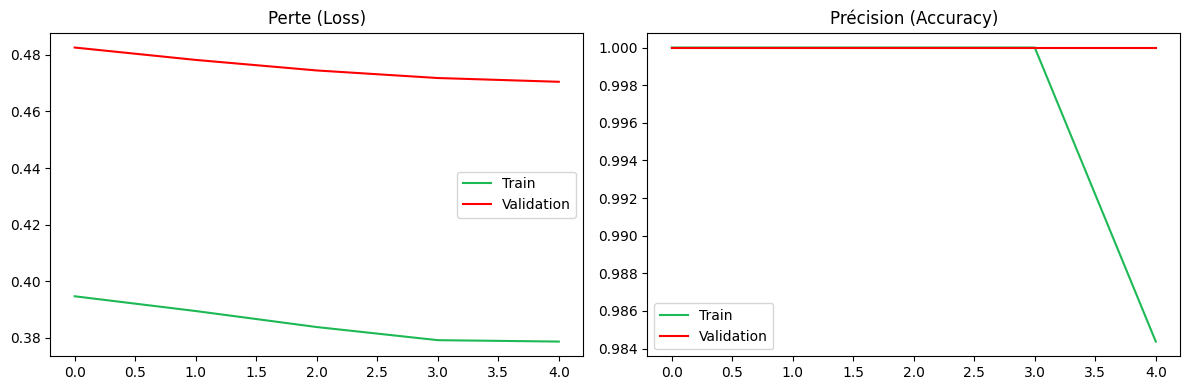

In [25]:
# Courbes d'apprentissage CNN
import matplotlib.pyplot as plt
import seaborn as sns

history = cnn_model.fit(
    X_img_train, y_img_train,
    epochs=5,
    validation_split=0.2,  # ← ajouter la validation !
    verbose=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train', color='#1DB954')
ax1.plot(history.history['val_loss'], label='Validation', color='red')
ax1.set_title("Perte (Loss)")
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train', color='#1DB954')
ax2.plot(history.history['val_accuracy'], label='Validation', color='red')
ax2.set_title("Précision (Accuracy)")
ax2.legend()

plt.tight_layout()
plt.show()